In [ ]:
#EDA
import pandas as pd 
import plotly.express as px
import plotly.figure_factory as ff
import matplotlib.pyplot as plt

#ML
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score


In [2]:
df = pd.read_csv('./datasets/diabetes.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   glicemia          995 non-null    int64
 1   pressao_arterial  995 non-null    int64
 2   diabetes          995 non-null    int64
dtypes: int64(3)
memory usage: 23.4 KB


In [4]:
df.head(10)

,glicemia,pressao_arterial,diabetes
0,40,85,0
1,40,92,0
2,45,63,1
3,45,80,0
4,40,73,1
5,45,82,0
6,40,85,0
7,30,63,1
8,65,65,1
9,45,82,0


In [5]:
df.rename(columns={
    'glicemia': 'glucose_level',
    'pressao_arterial': 'blood_pressure'
}, inplace=True)

In [6]:
df.head(10)

,glucose_level,blood_pressure,diabetes
0,40,85,0
1,40,92,0
2,45,63,1
3,45,80,0
4,40,73,1
5,45,82,0
6,40,85,0
7,30,63,1
8,65,65,1
9,45,82,0


### Target EDA

In [ ]:

px.bar(df.value_counts('diabetes'))

### Features EDA

In [12]:
px.histogram(df['glucose_level'], nbins=30)

In [11]:
px.histogram(df['blood_pressure'], nbins=30)

### Features x Target

In [13]:
px.box(df, x='diabetes', y='glucose_level', color='diabetes')

In [14]:
px.box(df, x='diabetes', y='blood_pressure', color='diabetes')

### Model Training

In [15]:
X = df.drop(columns=['diabetes'])
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [16]:
model_naive = GaussianNB()

model_naive.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[404.,392.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.51,0.49]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,8.72e-08
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['glucose_level','blood_pressure']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 2)","[[44.05,86.81], [44.55,71.68]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 2)","[[13.76,20.79], [74.61,39.55]]"


### Model Metrics

In [17]:
y_pred = model_naive.predict(X_test)

In [18]:
classification_report_str = classification_report(y_test, y_pred)
recall_baseline =  recall_score(y_test, y_pred, average='macro')
print(f'Report: \n{classification_report_str}')
print(f'Recall:\n{recall_baseline}')

Report: 
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        93
           1       0.93      0.93      0.93       106

    accuracy                           0.93       199
   macro avg       0.93      0.93      0.93       199
weighted avg       0.93      0.93      0.93       199

Recall:
0.9293467234733211


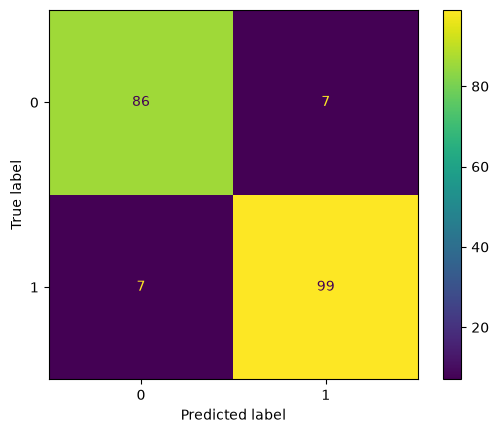

In [19]:
confusion_matrix_modelo_baseline = confusion_matrix(y_test, y_pred)
disp_model_baseline = ConfusionMatrixDisplay(confusion_matrix_modelo_baseline)
disp_model_baseline.plot()

### The Gaussian Naive Bayes model achieved strong performance in the diabetes classification task. It correctly classified 86 non-diabetic and 99 diabetic patients, with only 7 false positives and 7 false negatives. These results indicate high accuracy and a recall of approximately 0.93 for the positive class, showing that the model is effective at identifying patients with diabetes.